In [1]:
%pip install pymannkendall numpy tensorflow scikit-learn matplotlib keras-tuner

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Trend Prediction Testing Environment

This notebook is for evaluating different trend prediction algorithms for use in the main dashboard application

In [1]:
import json
# with open("original.json", "r") as fp:
with open("original_with_nlp.json", "r") as fp:
    data = json.load(fp)
    # filter out incomplete data
    data = list(
        filter(lambda x: x["BreachDate"].split("-")[0] != "2026", data))
algorithms = {}
allResults = {}

In [2]:
# Generate the test statistics (from dashboard-backend.py)
# Only significant difference is that the current year is ignored
import numpy as np
years = list(
    map(lambda x: int(x.get("BreachDate", "").split("-")[0]), data))
year_range = range(min(years), max(years)+1)
year_breach_counts = {year: years.count(year) for year in year_range}
year_records_counts = {year: 0 for year in year_range}
year_passwords_counts = {year: 0 for year in year_range}
year_data_classes = {year: 0 for year in year_range}
for i in range(len(data)):
    year_records_counts[years[i]] += data[i].get("PwnCount", 0)
    year_data_classes[years[i]] += len(data[i].get("DataClasses")) # type: ignore
    if "Passwords" in data[i].get("DataClasses", []):
        year_passwords_counts[years[i]] += data[i].get("PwnCount", 0)
year_avg_records = {
    year: year_records_counts[year]/year_breach_counts[year] for year in year_range
}
year_avg_data_classes = {
    year: year_data_classes[year]/year_breach_counts[year] for year in year_range
}

yearly_perc_hashed = {year: 0 for year in year_range}
yearly_perc_salted = {year: 0 for year in year_range}
year_password_breaches_counts = {year: 0 for year in year_range}
for i in range(len(data)):
    if "Passwords" in data[i].get("DataClasses", []):
        year_password_breaches_counts[years[i]] += 1
        if data[i].get("isHashed", False):
            yearly_perc_hashed[years[i]] += 1
            if data[i].get("isSalted", False):
                yearly_perc_salted[years[i]] += 1

# These statistics rely on NLP so don't include them to avoid a degree of uncertainty
yearly_perc_hashed = {year: (
    v / year_password_breaches_counts[year]) if year_password_breaches_counts[year] != 0 else 0
    for year, v in yearly_perc_hashed.items()}
yearly_perc_salted = {year: (
    v / year_password_breaches_counts[year]) if year_password_breaches_counts[year] != 0 else 0
    for year, v in yearly_perc_salted.items()}

yearlyHashFuncCounts = {algo: {year: len([None for i, d in enumerate(data) if d["hashAlgo"] == algo and years[i] == year])
                               for year in year_range}
                        for algo in sorted(set([x["hashAlgo"]
                                                for x in data if x["hashAlgo"] is not None]))}

# Testing data set
# data_set = (list(year_breach_counts.values()), list(year_records_counts.values()), list(year_avg_records.values()), list(year_passwords_counts.values()), list(year_password_breaches_counts.values()))

# Data set for implementation of LSTM
# data_set = [list(year_breach_counts.values()), list(year_records_counts.values()), list(year_avg_records.values()), list(
#     year_passwords_counts.values()), list(year_password_breaches_counts.values()), list(yearly_perc_hashed.values()), list(yearly_perc_salted.values())]
data_set = [list(year_avg_data_classes.values())]
# data_set.extend(map(lambda x: list(x.values()), yearlyHashFuncCounts.values()))
# Normalise values to reduce effect of large scales
data_set = np.array([(d - np.min(d)) / (np.max(d) - np.min(d))
                    for d in data_set])
# data_set_names = ["Breaches/Year", "Total Records/Year",
#                   "Avg. Records per Breach/Year", "Total Passwords/Year", "Password Breaches/Year"]
data_set_names = ["Avg. Data Classes per Breach/Year"]
data_set

array([[1.        , 0.21568627, 0.32773109, 0.41176471, 0.08496732,
        0.        , 0.20303605, 0.09449494, 0.24481793, 0.15319974,
        0.13787737, 0.2221504 , 0.21295347, 0.34316584, 0.30590418,
        0.14313266, 0.24004384, 0.19130005, 0.10460736]])

## Algorithm 1: Linear Regression

Simple linear regression algorithm considering all previous points.

In [ ]:
from scipy import stats


def linearRegression(series, n_predictions):
    slope, intercept, _, _, _ = stats.linregress(range(len(series)), series)
    # type: ignore
    return [intercept + slope*(len(series)+i) for i in range(n_predictions)], True


algorithms["Linear Regression"] = linearRegression
# import matplotlib.pyplot as plt
# plt.scatter(range(len(year_avg_records)), list(year_avg_records.values()))# + linearRegression(list(year_avg_records.values()), 5))
# plt.plot(range(len(year_avg_records), len(year_avg_records)+5), linearRegression(list(year_avg_records.values()), 5))

## Algorithm 2: Mann-Kendall

In [ ]:
import pymannkendall as mk
import numpy as np


def mannKendall(series, n_predictions):
    result = mk.original_test(series)
    if result.h or True:
        return [result.intercept + result.slope*(len(series)+i) for i in range(n_predictions)], result.h

    return None


algorithms["Mann-Kendall"] = mannKendall


def mannKendall2(series, n_predictions):
    # result = mk.partial_test(np.column_stack((series, np.arange(len(series)))))
    result = mk.hamed_rao_modification_test(series, lag=1)
    if result.h:
        return [result.intercept + result.slope*(len(series)+i) for i in range(n_predictions)]

    return None

# algorithms["Mann-Kendall2"] = mannKendall2

## Algorithm 3: Long Short-Term Memory

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

# TIME_STEP = 2 # Testing profile
TIME_STEP = 4
DEFAULT_PARAMS = {"units": 50, "learning_rate": 0.001, "epochs": 20}
# optimised_params=None


def lstm_prep(series):
    # Scale data
    # print(series)
    series = np.array(series)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(series.reshape(-1, 1))

    # Prepare the data for LSTM
    def create_dataset(series, time_step=1):
        X, y = [], []
        for i in range(len(series) - time_step - 1):
            X.append(series[i:(i + time_step), 0])
            y.append(series[i + time_step, 0])
        return np.array(X), np.array(y)

    X, y = create_dataset(scaled, TIME_STEP)
    # print(X)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    return X, y, scaled


def lstm_get_model(units, learning_rate):
    # Build the LSTM model
    model = Sequential()
    model.add(Input((TIME_STEP, 1)))
    model.add(LSTM(units=units, return_sequences=True))
    model.add(LSTM(units=units))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mean_squared_error')
    return model


def lstm(series, nPredictions, params=DEFAULT_PARAMS):
    """
    Long Short-Term Memory trend prediction.

    Derived from https://www.statology.org/how-to-build-lstm-models-for-time-series-prediction-in-python/
    Also helpful: https://www.geeksforgeeks.org/deep-learning/long-short-term-memory-lstm-rnn-in-tensorflow/
    """
    # Reset tensorflow
    # tf.keras.backend.clear_session()

    X, y, scaled = lstm_prep(series)
    # model = lstm_get_model(60, 0.01)
    model = lstm_get_model(params["units"], params["learning_rate"])

    # Train the model
    # model.fit(X, y, epochs=31)#, batch_size=32, )
    model.fit(X, y, epochs=params["epochs"], batch_size=32, )

    # Forecast future values
    # forecast = model.predict(X[-(nPredictions+1):])
    x = np.array([scaled[-TIME_STEP:, 0]])
    x = x.reshape(x.shape[0], x.shape[1], 1)
    predicted = scaled[-TIME_STEP:, 0].flatten()
    for _ in range(nPredictions):
        # Input [x0, x1, ..., xi] -> output [x(i+1)]
        # print(model.predict(x))
        predicted = np.append(predicted, model.predict(x)[0, 0])
        x = np.array([predicted[-TIME_STEP]])
        x = x.reshape(x.shape[0], 1, 1)

    # Inverse transform to original scale
    # forecast = scaler.inverse_transform(forecast)

    # print("Forecasted values:", forecast)
    print(predicted)
    return predicted[-nPredictions:], True


algorithms["LSTM"] = lstm

2026-03-20 11:01:41.739272: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-20 11:01:41.748781: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-20 11:01:42.674264: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-20 11:01:45.167220: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [4]:
# Use the Keras Tuner package (https://www.tensorflow.org/tutorials/keras/keras_tuner)
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping
from multiprocessing import Pool


def lstm_param_tuning(X, y, id):
    def model_builder(hp): return lstm_get_model(hp.Int('units', min_value=20,
                                                        max_value=80, step=10), hp.Choice('learning_rate', values=[0.01, 0.001, 0.0001]))
    tuner = kt.Hyperband(model_builder,
                         objective=kt.Objective('val_loss', "min"),
                         max_epochs=10,
                         factor=3,
                         directory='kt_dir',
                         project_name=f'lstm-{7}')
    stop_early = EarlyStopping(monitor='val_loss', patience=5)
    tuner.search(X, y, epochs=50, validation_split=0.2,
                 callbacks=[stop_early], )
    # Get the optimal hyperparameters
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"""Best units: {best_hps.get('units')}
Best learning rate for the optimizer: {best_hps.get('learning_rate')}""")
    return tuner.hypermodel.build(best_hps), best_hps  # type: ignore


def lstm_epoch_tuning(model, X, y):
    history = model.fit(X, y, epochs=50, validation_split=0.2)

    val_acc_per_epoch = history.history['val_loss']
    best_epoch = val_acc_per_epoch.index(min(val_acc_per_epoch)) + 1
    print(f"Best epoch: {best_epoch}")
    return best_epoch


def lstm_tuning_results(model, best_epoch, X, y, test_X, test_y):
    # Retrain the model
    model.fit(X, y, epochs=best_epoch, validation_split=0.2)
    eval_result = model.evaluate(test_X, test_y)
    print("test loss:", eval_result)


def lstm_run_training(a):
    i, d = a
    X, y, _ = lstm_prep(d)
    hypermodel, best_hps = lstm_param_tuning(X, y, i)
    epoch = lstm_epoch_tuning(hypermodel, X, y)
    # test_X, test_y,_ = lstm_prep(d[-3:])
    # print(f"Data set {i}:")
    # lstm_tuning_results(hypermodel, epoch, X, y, test_X, test_y)
    return {"units": best_hps.get("units"), "learning_rate": best_hps.get("learning_rate"), "epochs": epoch}


optimised_params = []

# with Pool(3) as p:
#     optimised_params = p.map(lstm_run_training, enumerate(data_set))
optimised_params = list(map(lstm_run_training, enumerate(data_set)))

Trial 29 Complete [00h 00m 04s]
val_loss: 0.0018542770994827151

Best val_loss So Far: 0.0015433415537700057
Total elapsed time: 00h 01m 42s
Best units: 50
Best learning rate for the optimizer: 0.01
Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0424 - val_loss: 0.0048
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0150 - val_loss: 0.0131
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0248 - val_loss: 0.0044
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0154 - val_loss: 0.0018
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0115 - val_loss: 0.0046
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0131 - val_loss: 0.0059
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0136 - val_loss: 0.0049
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0123 - val_loss: 0.0032
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0107 - val_loss: 0.0020
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - lo

In [5]:
# optimised_params = [{'units': 70, 'learning_rate': 0.01, 'epochs': 8},
#                     {'units': 20, 'learning_rate': 0.01, 'epochs': 4},
#                     {'units': 20, 'learning_rate': 0.01, 'epochs': 1},
#                     {'units': 20, 'learning_rate': 0.01, 'epochs': 2},
#                     {'units': 50, 'learning_rate': 0.01, 'epochs': 13}]
optimised_params

[{'units': 50, 'learning_rate': 0.01, 'epochs': 27}]

## Evaluation

In [ ]:
NO_VALUES_TO_TEST = 3

for algo in algorithms:
    results = []
    for index, instance in enumerate(data_set):
        training_data = instance[:-NO_VALUES_TO_TEST]
        test_data = instance[-NO_VALUES_TO_TEST:]
        if algo == "LSTM" and optimised_params is not None:
            output, _ = algorithms[algo](
                training_data, NO_VALUES_TO_TEST, optimised_params[index])
        else:
            output, _ = algorithms[algo](training_data, NO_VALUES_TO_TEST)
        if output is None:
            print("No trend found")
            # continue
        print(output)
        score = 0
        for i in range(NO_VALUES_TO_TEST):
            score += ((output[i]-test_data[i])**2)/NO_VALUES_TO_TEST
        results.append(score)
    avg = sum(results)/len(results)
    print(f"{algo}: {avg}")
    allResults[algo] = avg

[np.float64(0.9902912621359223), np.float64(1.0538977727013135), np.float64(1.1175042832667048)]
[np.float64(0.47681569148284886), np.float64(0.5063091921033828), np.float64(0.5358026927239167)]
[np.float64(0.06730847822757646), np.float64(0.05651055743041952), np.float64(0.04571263663326258)]
[np.float64(0.341731432101412), np.float64(0.3589715239191415), np.float64(0.37621161573687106)]
[np.float64(0.8825301204819278), np.float64(0.935772501771793), np.float64(0.9890148830616585)]
Linear Regression: 0.20108734854704263
[np.float64(1.0426412180052957), np.float64(1.1076235657546336), np.float64(1.172605913503972)]
[np.float64(0.36434316383575216), np.float64(0.39107214744881713), np.float64(0.4178011310618821)]
[np.float64(0.12082427370781543), np.float64(0.1244568005595941), np.float64(0.12808932741137274)]
[np.float64(0.3337032765539041), np.float64(0.35573447505701916), np.float64(0.37776567356013435)]
[np.float64(0.9304718875502007), np.float64(0.9882028112449799), np.float64(1.04

2026-03-09 10:37:26.895439: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.3749
Epoch 2/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2664
Epoch 3/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1603
Epoch 4/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0662
Epoch 5/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0661
Epoch 6/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1178
Epoch 7/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0776
Epoch 8/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0445
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[0.73786408 0.58252427 0.61272454 0.26872215 0.27427652]
[0.61272454 0.26872215 0.27427652]
Epoch 1/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1473
Epoch 2/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1201
Epoch 3/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0976
Epoch 4/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0793
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━

Text(0.72, 0.2, 'Score:\n0.221')

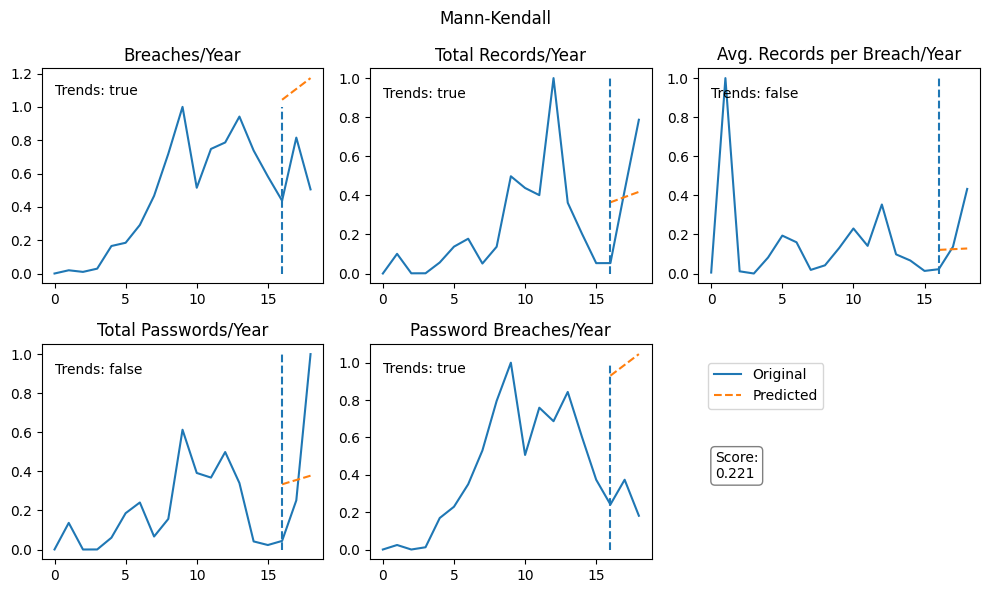

In [ ]:
import matplotlib.pyplot as plt

# index = 1
# instance = data_set[index]
algo = "Mann-Kendall"
NO_VALUES_TO_SHOW = 3

f = plt.figure()
f.set_figheight(6)
f.set_figwidth(10)

for index, instance in enumerate(data_set):
    training_data = instance[:-NO_VALUES_TO_SHOW]
    test_data = instance[-NO_VALUES_TO_SHOW:]
    if algo == "LSTM" and optimised_params is not None:
        output, _ = algorithms[algo](
            training_data, NO_VALUES_TO_SHOW, optimised_params[index])
    else:
        output, trends = algorithms[algo](training_data, NO_VALUES_TO_SHOW)

    plt.subplot(2, 3, index+1)
    plt.title(f"{data_set_names[index]}")
    plt.plot(range(len(instance)), instance, label="Original")
    plt.plot(range(len(instance)-NO_VALUES_TO_SHOW, len(instance)),
             output, linestyle="--", label="Predicted")
    plt.vlines(len(instance)-NO_VALUES_TO_SHOW, 0, 1, linestyle="--")
    if algo == "Mann-Kendall":
        plt.text(0, max(max(output), max(instance))-0.1,
                 f"Trends: {"true" if trends else "false"}")
    # plt.legend()

plt.suptitle(algo)
plt.tight_layout()
plt.legend(loc=(1.2, 0.7))
plt.figtext(0.72, 0.2, f"Score:\n{allResults[algo]:0.3}", bbox={
            "boxstyle": "round", "color": "grey", "fill": False})